# Flood Risk Monitoring & Mitigation — Experimentation Lab

**Module:** `arin_climate_dss.flood`  
**Study area:** Inner Niger Delta, Mali  
**Flood event:** Niger River annual flood pulse — October–November 2020  
**Architecture role:** Domain layer — feeds `FloodRiskUseCase` in `use_case.py`

---

## Pipeline

| § | Step | Source |
|---|------|--------|
| 1 | Terrain — DEM, Slope, Aspect | SRTM 30 m (`USGS/SRTMGL1_003`) |
| 2 | Flow Accumulation & TWI | HydroSHEDS (`WWF/HydroSHEDS/30ACC`) |
| 3 | SAR Backscatter Change | Sentinel-1 GRD (`COPERNICUS/S1_GRD`) |
| 4 | Cumulative Rainfall | CHIRPS daily (`UCSB-CHG/CHIRPS/DAILY`) |
| 5 | Land Cover | ESA WorldCover 2021 (`ESA/WorldCover/v200`) |
| 6 | Distance to Rivers | JRC GSW (`JRC/GSW1_4/GlobalSurfaceWater`) |
| 7 | MNDWI Water Index | Sentinel-2 SR (`COPERNICUS/S2_SR_HARMONIZED`) |
| 8 | Feature Stack & Sampling | GEE `.sample()` → pandas |
| 9 | **Independent Flood Labels** | **JRC Monthly History (Landsat-derived)** |
|10 | Random Forest Classifier | scikit-learn |
|11 | XGBoost Classifier | xgboost |
|12 | Model Evaluation | F1, ROC-AUC, confusion matrix |
|13 | SHAP Feature Importance | shap TreeExplainer |
|14 | 4-Class Risk Map | RF + XGBoost ensemble |
|15 | Spatial Uncertainty | RF–XGBoost probability spread |
|16 | Frontend Chart Payloads | JSON-serialisable dicts |
|17 | COG Export | Placeholder for `use_case.py` |

---

**Data extraction pattern:** GEE image → `getDownloadURL()` → `requests` → `rioxarray` (in-memory)

**Output schema** (matches `FloodRiskUseCase.run()`):
```
{
  stats:  { area_km2, risk_%, rf_f1, xgb_auc, … }
  charts: { risk_distribution, shap, uncertainty, model_performance }
  raster: { flood_risk: 'outputs/flood_2020_inner_niger_delta_risk.tif' }
}
```

In [1]:
%matplotlib inline
import io
import json
import warnings

import ee
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import rioxarray as rxr
import xarray as xr

plt.rcParams["figure.dpi"] = 110

In [2]:
ee.Authenticate()
ee.Initialize(project="parallelprocessing-433914")

---
## §1 — Terrain: DEM, Slope, Aspect

Source: **USGS SRTM 30 m** (`USGS/SRTMGL1_003`).  
Reprojected to EPSG:4326 at 500 m for GEE computation, downloaded at 90 m native resolution.

- **Elevation** — base terrain height (m)
- **Slope** — steepness in degrees; flat areas accumulate water
- **Aspect** — solar/wind exposure; used with slope for terrain wetness modelling

In [3]:
# Inner Niger Delta, Mali — [min_lon, min_lat, max_lon, max_lat]
bbox = [-4.5, 13.5, -3.0, 15.5]
aoi = ee.Geometry.Rectangle(bbox)

area_km2 = aoi.area().divide(1e6).getInfo()
print(f"AOI: {bbox}  |  area: {area_km2:,.0f} km²")

dem = ee.Image("USGS/SRTMGL1_003").select("elevation").reproject("EPSG:4326", None, 500)
terrain = ee.Terrain.products(dem)

combined_img = dem.addBands(terrain.select(["slope", "aspect"]))

AOI: [-4.5, 13.5, -3.0, 15.5]  |  area: 35,911 km²


In [4]:
# Generate temporary download URL
url = combined_img.getDownloadURL(
    {"region": aoi, "scale": 90, "crs": "EPSG:4326", "format": "GEO_TIFF"}
)

In [5]:
# Download DEM GeoTIFF into memory
response = requests.get(url)
response.raise_for_status()
memory_file = io.BytesIO(response.content)

dem_ds = rxr.open_rasterio(memory_file)

band_names = ["elevation", "slope", "aspect"]
dem_ds = dem_ds.assign_coords(band=band_names)
dem_ds = dem_ds.to_dataset(dim="band")
dem_ds = dem_ds.rename({"x": "lon", "y": "lat"})
dem_ds

<xarray.Dataset> Size: 28MB
Dimensions:      (lat: 2477, lon: 1856)
Coordinates:
  * lon          (lon) float64 15kB -4.5 -4.499 -4.498 ... -3.001 -3.001 -3.0
  * lat          (lat) float64 20kB 15.5 15.5 15.5 15.5 ... 13.5 13.5 13.5 13.5
    spatial_ref  int64 8B 0
Data variables:
    elevation    (lat, lon) int16 9MB ...
    slope        (lat, lon) int16 9MB ...
    aspect       (lat, lon) int16 9MB ...
Attributes:
    AREA_OR_POINT:           Area
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    _FillValue:              -32768
    scale_factor:            1.0
    add_offset:              0.0

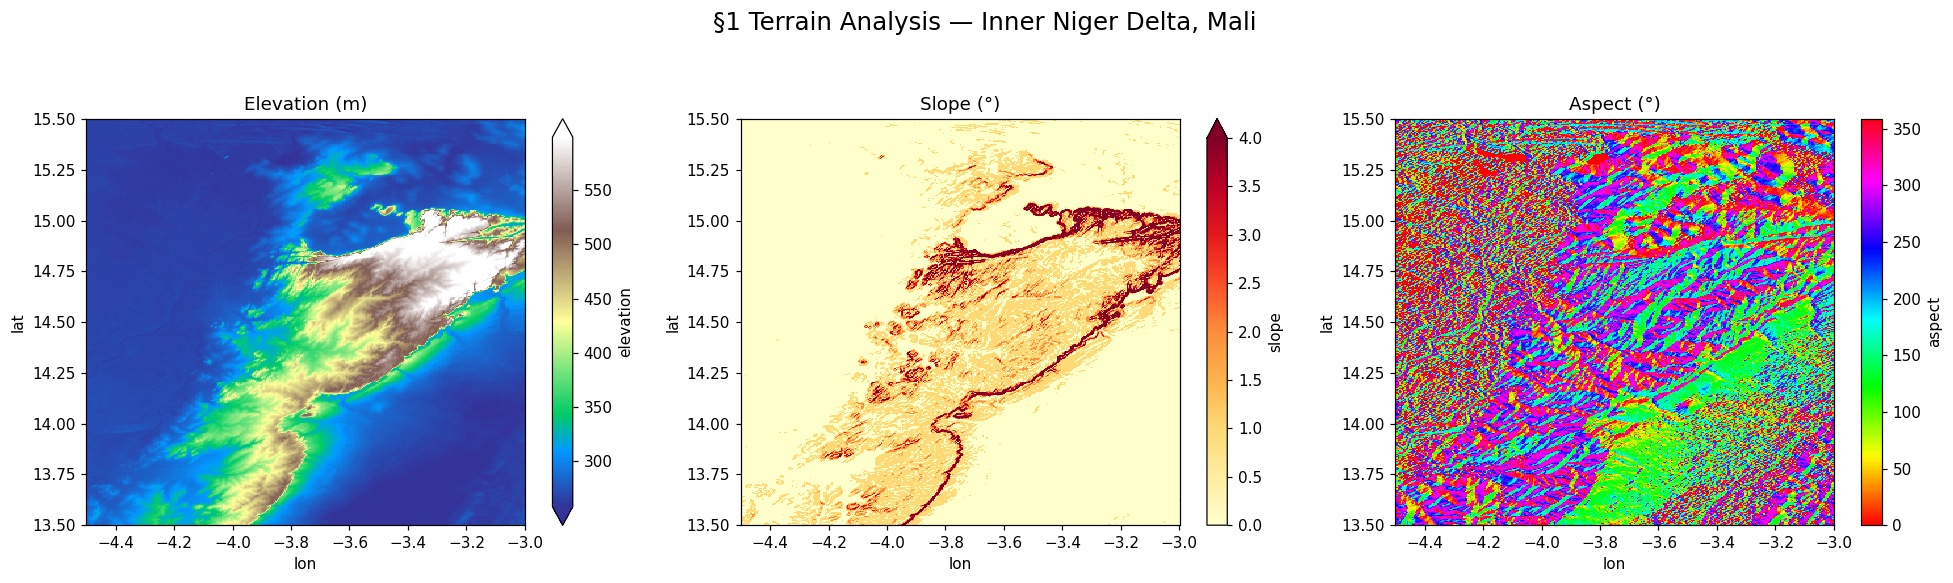

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

dem_ds["elevation"].plot(ax=axes[0], cmap="terrain", robust=True)
axes[0].set_title("Elevation (m)")

dem_ds["slope"].plot(ax=axes[1], cmap="YlOrRd", robust=True)
axes[1].set_title("Slope (°)")

dem_ds["aspect"].plot(ax=axes[2], cmap="hsv")
axes[2].set_title("Aspect (°)")

plt.suptitle("§1 Terrain Analysis — Inner Niger Delta, Mali", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

---
## §2 — Flow Accumulation & Topographic Wetness Index (TWI)

**TWI = ln(flow_accumulation / tan(slope))**  
High TWI → gentle slopes with large upstream drainage area → terrain that traps water.  
Source: HydroSHEDS 30 arc-second flow accumulation (`WWF/HydroSHEDS/30ACC`).

In [7]:
# HydroSHEDS flow accumulation (pixels × upstream area at ~900 m resolution)
flow_acc = ee.Image("WWF/HydroSHEDS/30ACC").select("b1").clip(aoi)

# Extract slope from §1 terrain products; clamp to ≥ 0.001 rad to avoid log(∞)
slope = terrain.select("slope").clip(aoi)
slope_rad = slope.multiply(np.pi / 180).max(ee.Image(0.001))
slope_tan = slope_rad.tan()

# Scale pixels to m² (~900 m resolution → 810 000 m²/pixel)
flow_acc_m2 = flow_acc.multiply(810_000)
twi = flow_acc_m2.divide(slope_tan).log().rename("twi").clip(aoi)
flow_acc_log = flow_acc.add(1).log().rename("flow_acc_log").clip(aoi)

# Download both bands
url = twi.addBands(flow_acc_log).getDownloadURL(
    {
        "region": aoi,
        "scale": 500,
        "crs": "EPSG:4326",
        "format": "GEO_TIFF",
    }
)
response = requests.get(url)
response.raise_for_status()
memory_file = io.BytesIO(response.content)

twi_raw = rxr.open_rasterio(memory_file)
twi_raw = twi_raw.assign_coords(band=["twi", "flow_acc_log"])
twi_ds = twi_raw.to_dataset(dim="band").rename({"x": "lon", "y": "lat"})
twi_ds

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


<xarray.Dataset> Size: 2MB
Dimensions:       (lat: 446, lon: 335)
Coordinates:
  * lon           (lon) float64 3kB -4.498 -4.494 -4.489 ... -3.003 -2.998
  * lat           (lat) float64 4kB 15.5 15.49 15.49 15.48 ... 13.51 13.5 13.5
    spatial_ref   int64 8B 0
Data variables:
    twi           (lat, lon) float64 1MB ...
    flow_acc_log  (lat, lon) float64 1MB ...
Attributes:
    AREA_OR_POINT:           Area
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    scale_factor:            1.0
    add_offset:              0.0

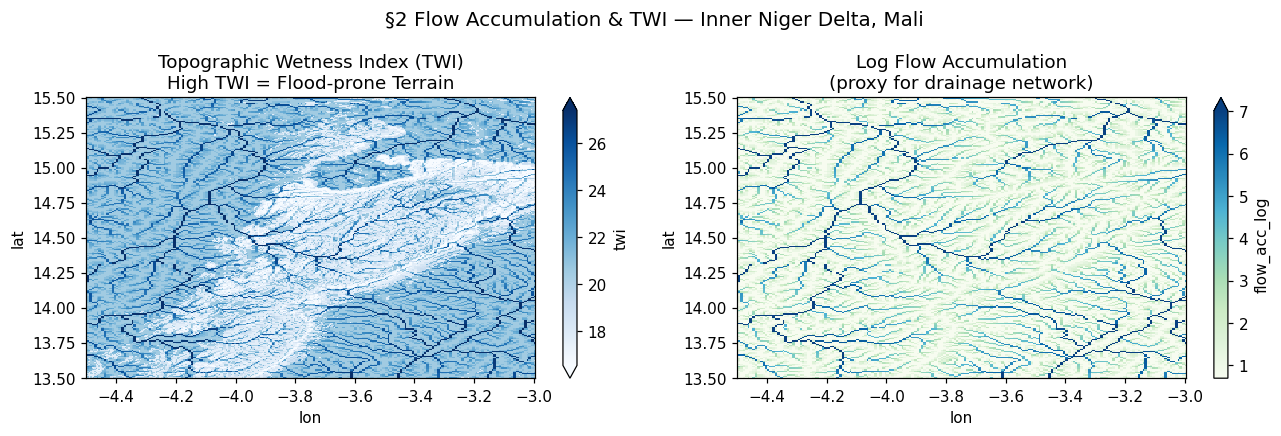

TWI range: [14.56, 33.31]


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
twi_ds["twi"].plot(ax=axes[0], cmap="Blues", robust=True)
axes[0].set_title("Topographic Wetness Index (TWI)\nHigh TWI = Flood-prone Terrain")
twi_ds["flow_acc_log"].plot(ax=axes[1], cmap="GnBu", robust=True)
axes[1].set_title("Log Flow Accumulation\n(proxy for drainage network)")
plt.suptitle("§2 Flow Accumulation & TWI — Inner Niger Delta, Mali", fontsize=13)
plt.tight_layout()
plt.show()

print(
    f"TWI range: [{float(twi_ds['twi'].min()):.2f}, {float(twi_ds['twi'].max()):.2f}]"
)

---
## §3 — Sentinel-1 SAR Flood Detection

**Approach:** Compare pre-flood and peak-flood C-band VV backscatter.  
Open water is a specular reflector → **VV drops sharply** during flooding.  
Change = pre − flood (positive value = backscatter drop = flood/open-water signal).

| Period | Dates | Role |
|--------|-------|------|
| Pre-flood baseline | Jul–Aug 2020 | Dry season, before Niger flood wave |
| Flood peak | Oct–Nov 2020 | Niger River inundation of the Inner Delta |

In [9]:
sar = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(aoi)
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
    .filter(ee.Filter.eq("orbitProperties_pass", "ASCENDING"))
    .select("VV")
)

pre_flood_sar = sar.filterDate("2020-07-01", "2020-08-31").mean().clip(aoi)
flood_sar = sar.filterDate("2020-10-01", "2020-11-30").mean().clip(aoi)

# Positive = backscatter was higher before flooding (open water → specular loss)
vv_change = pre_flood_sar.subtract(flood_sar).rename("vv_change")

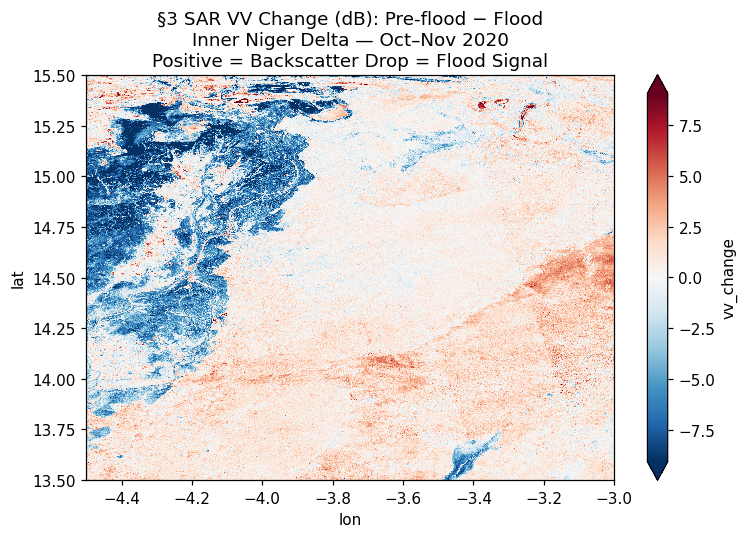

Mean VV change: -0.39 dB
Max  VV change: 15.11 dB


In [10]:
url = vv_change.getDownloadURL(
    {
        "region": aoi,
        "scale": 90,
        "crs": "EPSG:4326",
        "format": "GEO_TIFF",
    }
)
response = requests.get(url)
response.raise_for_status()
memory_file = io.BytesIO(response.content)

sar_raw = rxr.open_rasterio(memory_file).squeeze()
sar_ds = xr.Dataset({"vv_change": sar_raw.rename({"x": "lon", "y": "lat"})})

fig, ax = plt.subplots(figsize=(7, 5))
sar_ds["vv_change"].plot(ax=ax, cmap="RdBu_r", robust=True)
ax.set_title(
    "§3 SAR VV Change (dB): Pre-flood − Flood\n"
    "Inner Niger Delta — Oct–Nov 2020\n"
    "Positive = Backscatter Drop = Flood Signal"
)
plt.tight_layout()
plt.show()

print(f"Mean VV change: {float(sar_ds['vv_change'].mean()):.2f} dB")
print(f"Max  VV change: {float(sar_ds['vv_change'].max()):.2f} dB")

---
## §4 — CHIRPS Cumulative Rainfall

Source: **CHIRPS daily** (`UCSB-CHG/CHIRPS/DAILY`).  
The Niger River flood pulse in the Inner Delta is driven by rainfall in the Guinea Highlands  
weeks before the wave arrives. Local October rainfall amplifies surface runoff.

- **7-day cumulative** (25–31 Oct 2020) — immediate pre-peak rainfall
- **30-day cumulative** (October 2020) — seasonal accumulation driving the flood wave

In [11]:
chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY").filterBounds(aoi)

rainfall_7d = (
    chirps.filterDate("2020-10-25", "2020-10-31").sum().clip(aoi).rename("rainfall_7d")
)
rainfall_30d = (
    chirps.filterDate("2020-10-01", "2020-10-31").sum().clip(aoi).rename("rainfall_30d")
)

In [12]:
rainfall = rainfall_7d.addBands(rainfall_30d)

url = rainfall.getDownloadURL(
    {"region": aoi, "scale": 500, "crs": "EPSG:4326", "format": "GEO_TIFF"}
)

In [13]:
response = requests.get(url)
response.raise_for_status()

memory_file = io.BytesIO(response.content)

rain_ds = rxr.open_rasterio(memory_file)

rain_ds = rain_ds.assign_coords(band=["rainfall_7d", "rainfall_30d"])

rain_ds = rain_ds.to_dataset(dim="band")
rain_ds = rain_ds.rename({"x": "lon", "y": "lat"})

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


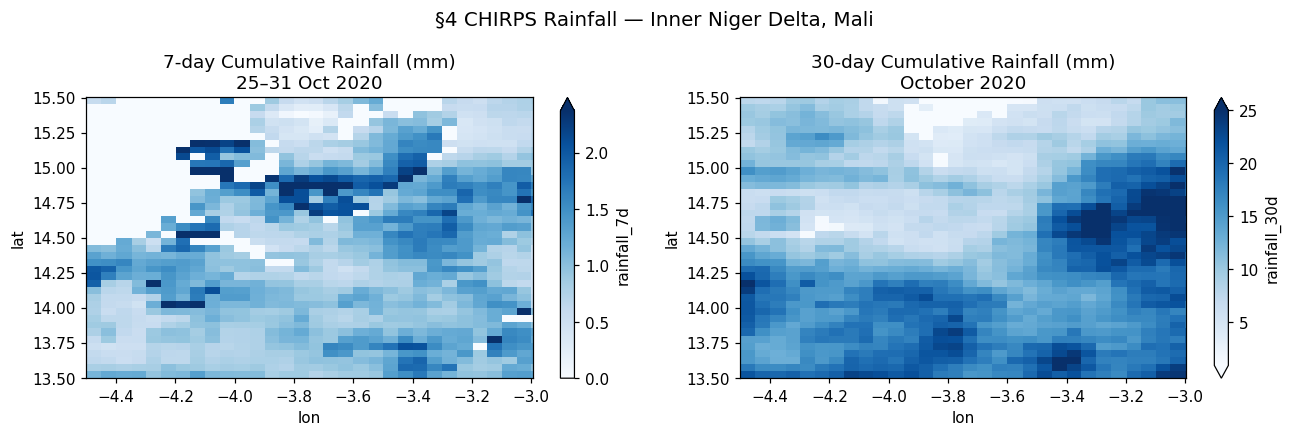

Max 7-day rainfall  : 3.6 mm
Max 30-day rainfall : 31.4 mm


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rain_ds["rainfall_7d"].plot(ax=axes[0], cmap="Blues", robust=True)
axes[0].set_title("7-day Cumulative Rainfall (mm)\n25–31 Oct 2020")
rain_ds["rainfall_30d"].plot(ax=axes[1], cmap="Blues", robust=True)
axes[1].set_title("30-day Cumulative Rainfall (mm)\nOctober 2020")
plt.suptitle("§4 CHIRPS Rainfall — Inner Niger Delta, Mali", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Max 7-day rainfall  : {float(rain_ds['rainfall_7d'].max()):.1f} mm")
print(f"Max 30-day rainfall : {float(rain_ds['rainfall_30d'].max()):.1f} mm")

---
## §5 — ESA WorldCover 2021 — Land Cover

Source: **ESA WorldCover v200** 10 m (`ESA/WorldCover/v200`).  
Land cover determines infiltration capacity and surface runoff.  
Urban areas and bare soil have low infiltration → higher flood risk.

In [15]:
# WorldCover classes: 10=Tree, 20=Shrub, 30=Grass, 40=Crop, 50=Built,
#                     60=Bare, 80=Water, 90=Wetland, 95=Mangrove
worldcover = ee.ImageCollection("ESA/WorldCover/v200").first().select("Map").clip(aoi)
landcover_norm = worldcover.divide(10).subtract(1).rename("landcover")

url = worldcover.getDownloadURL(
    {
        "region": aoi,
        "scale": 100,
        "crs": "EPSG:4326",
        "format": "GEO_TIFF",
    }
)
response = requests.get(url)
response.raise_for_status()
memory_file = io.BytesIO(response.content)

lc_raw = rxr.open_rasterio(memory_file).squeeze()
lc_ds = xr.Dataset({"Map": lc_raw.rename({"x": "lon", "y": "lat"})})
lc_ds

<xarray.Dataset> Size: 4MB
Dimensions:      (lon: 1671, lat: 2228)
Coordinates:
    band         int64 8B 1
  * lon          (lon) float64 13kB -4.5 -4.499 -4.498 ... -3.002 -3.001 -3.0
  * lat          (lat) float64 18kB 15.5 15.5 15.5 15.5 ... 13.5 13.5 13.5 13.5
    spatial_ref  int64 8B 0
Data variables:
    Map          (lat, lon) uint8 4MB ...

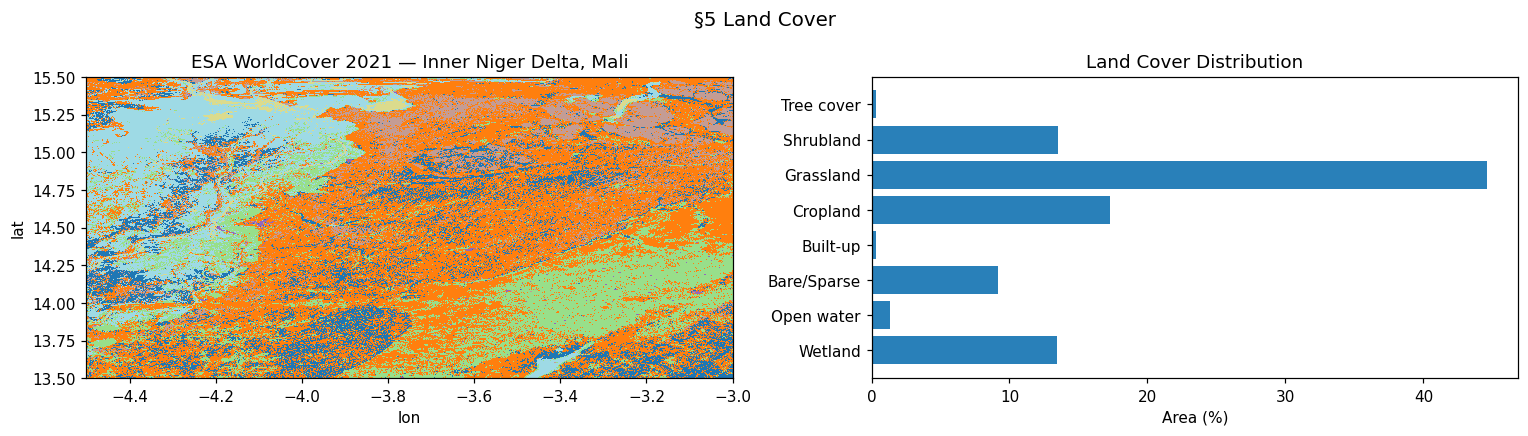

In [16]:
LC_LABELS = {
    10: "Tree cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare/Sparse",
    80: "Open water",
    90: "Wetland",
    95: "Mangrove",
}

lc_vals = lc_ds["Map"].values.flatten()
lc_vals = lc_vals[~np.isnan(lc_vals)]
unique, counts = np.unique(lc_vals.astype(int), return_counts=True)
labels = [LC_LABELS.get(v, f"Class {v}") for v in unique]
pcts = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
lc_ds["Map"].plot(ax=axes[0], cmap="tab20", robust=True, add_colorbar=False)
axes[0].set_title("ESA WorldCover 2021 — Inner Niger Delta, Mali")
axes[1].barh(labels[::-1], pcts[::-1], color="#2980B9")
axes[1].set_xlabel("Area (%)")
axes[1].set_title("Land Cover Distribution")
plt.suptitle("§5 Land Cover", fontsize=13)
plt.tight_layout()
plt.show()

---
## §6 — Distance to Rivers

Source: **JRC Global Surface Water** (`JRC/GSW1_4/GlobalSurfaceWater`).  
Pixels with water occurrence ≥ 70 % define the permanent river network.  
Distance to this network is computed via a fast distance transform.

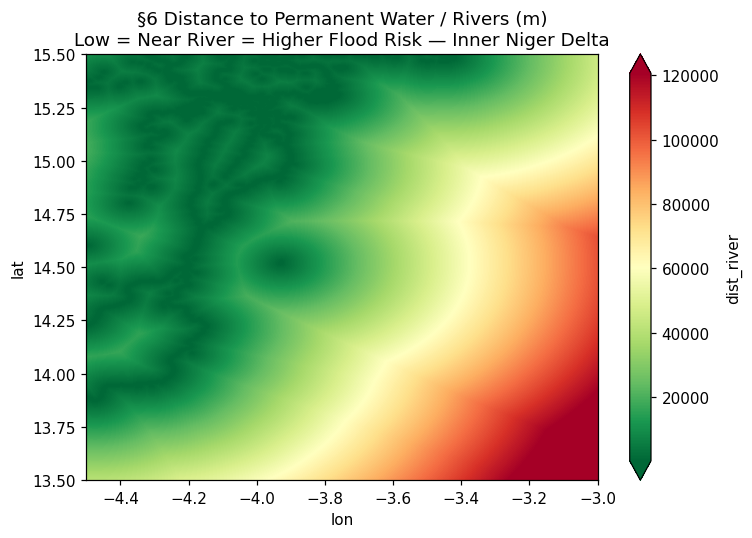

In [17]:
jrc = ee.Image("JRC/GSW1_4/GlobalSurfaceWater")

# Permanent water mask: occurrence ≥ 70 %
water_mask = jrc.select("occurrence").gte(70).clip(aoi)

# Euclidean distance transform: pixels → metres
dist_river = (
    water_mask.fastDistanceTransform(256, "pixels")
    .sqrt()
    .multiply(ee.Image.pixelArea().sqrt())
    .rename("dist_river")
    .clip(aoi)
)

url = dist_river.getDownloadURL(
    {
        "region": aoi,
        "scale": 90,
        "crs": "EPSG:4326",
        "format": "GEO_TIFF",
    }
)
response = requests.get(url)
response.raise_for_status()
memory_file = io.BytesIO(response.content)

dist_raw = rxr.open_rasterio(memory_file).squeeze()
dist_ds = xr.Dataset({"dist_river": dist_raw.rename({"x": "lon", "y": "lat"})})

fig, ax = plt.subplots(figsize=(7, 5))
dist_ds["dist_river"].plot(ax=ax, cmap="RdYlGn_r", robust=True)
ax.set_title(
    "§6 Distance to Permanent Water / Rivers (m)\n"
    "Low = Near River = Higher Flood Risk — Inner Niger Delta"
)
plt.tight_layout()
plt.show()

---
## §7 — Sentinel-2 MNDWI (Water Index)

**MNDWI = (Green − SWIR1) / (Green + SWIR1)**  
Positive MNDWI reliably separates open water and flooded surfaces from dry land.  
Source: **Sentinel-2 SR Harmonized** (`COPERNICUS/S2_SR_HARMONIZED`).  
Composite: **Oct–Nov 2020 median** (peak flood period, cloud cover < 30 %).

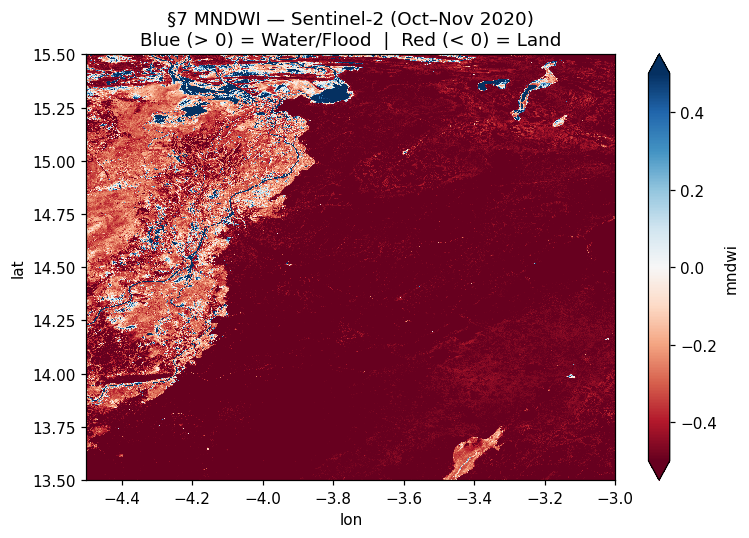

Fraction of pixels with MNDWI > 0 (water signal): 4.2%


In [18]:
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate("2020-10-01", "2020-11-30")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
    .select(["B3", "B11"])  # Green, SWIR1
    .median()
    .clip(aoi)
)

mndwi = s2.normalizedDifference(["B3", "B11"]).rename("mndwi")

url = mndwi.getDownloadURL(
    {
        "region": aoi,
        "scale": 90,
        "crs": "EPSG:4326",
        "format": "GEO_TIFF",
    }
)
response = requests.get(url)
response.raise_for_status()
memory_file = io.BytesIO(response.content)

mndwi_raw = rxr.open_rasterio(memory_file).squeeze()
mndwi_ds = xr.Dataset({"mndwi": mndwi_raw.rename({"x": "lon", "y": "lat"})})

fig, ax = plt.subplots(figsize=(7, 5))
mndwi_ds["mndwi"].plot(ax=ax, cmap="RdBu", vmin=-0.5, vmax=0.5)
ax.set_title(
    "§7 MNDWI — Sentinel-2 (Oct–Nov 2020)\n"
    "Blue (> 0) = Water/Flood  |  Red (< 0) = Land"
)
plt.tight_layout()
plt.show()

water_fraction = float((mndwi_ds["mndwi"] > 0).mean())
print(f"Fraction of pixels with MNDWI > 0 (water signal): {water_fraction * 100:.1f}%")

---
## §8 — Feature Stack & Point Sampling

Stack all 10 features into a single multi-band GEE image and sample
5 000 random points at 90 m resolution → pandas DataFrame for sklearn.

In [19]:
FEATURE_COLS = [
    "elevation",  # m
    "twi",  # Topographic Wetness Index
    "dist_river",  # m to nearest permanent water
    "vv_change",  # SAR backscatter change (pre − flood), dB
    "rainfall_7d",  # 7-day cumulative rainfall, mm
    "rainfall_30d",  # 30-day cumulative rainfall, mm
    "mndwi",  # Modified NDWI
    "landcover",  # ESA WorldCover encoded (0-based)
    "longitude",  # pixel longitude — east–west position in the delta
    "latitude",  # pixel latitude  — north–south flood gradient
]
# Dropped: slope (mean |SHAP| ≈ 0.02) and flow_acc_log (≈ 0.08) — negligible contribution

coords = ee.Image.pixelLonLat().rename(["longitude", "latitude"]).clip(aoi)

feature_stack = ee.Image.cat(
    [
        dem.select("elevation"),
        twi,
        dist_river,
        vv_change,
        rainfall_7d,
        rainfall_30d,
        mndwi,
        landcover_norm,
        coords,
    ]
)

print(f"Feature stack: {len(FEATURE_COLS)} bands (dropped: slope, flow_acc_log)")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {col}")

Feature stack: 10 bands (dropped: slope, flow_acc_log)
   1. elevation
   2. twi
   3. dist_river
   4. vv_change
   5. rainfall_7d
   6. rainfall_30d
   7. mndwi
   8. landcover
   9. longitude
  10. latitude


---
## §9 — Independent Flood Labels (JRC Monthly History)

Labels are derived from the **JRC Global Surface Water Monthly History** dataset
(`JRC/GSW1_4/MonthlyHistory`), which is built from **Landsat** imagery — entirely
independent of our Sentinel-1 and Sentinel-2 features, eliminating data leakage.

**Logic:**

| Step | Dataset | Period | Role |
|------|---------|--------|------|
| Flood water | JRC Monthly History (value = 2) | Oct–Nov 2020 | Water present during flood peak |
| Dry baseline | JRC Monthly History (value = 2) | Jun–Aug 2020 | Permanent / pre-flood water |
| **Label = 1** | flood water AND NOT dry baseline | — | New inundation (not always-wet rivers) |

This ensures the model must learn from terrain, hydrology, SAR, rainfall, and land cover —
not from the water index or SAR change used to define the labels.

In [20]:
# JRC Yearly History 2020: 0=no data, 1=not water, 2=seasonal, 3=permanent
jrc_yearly = ee.ImageCollection("JRC/GSW1_4/YearlyHistory")

flood_year = jrc_yearly.filterDate("2020-01-01", "2020-12-31").first().clip(aoi)

# Long-term permanent water baseline (occurrence ≥ 75% across 1984–2021)
jrc_summary = ee.Image("JRC/GSW1_4/GlobalSurfaceWater")
permanent_baseline = jrc_summary.select("occurrence").gte(75).clip(aoi)

# Label = seasonal water in 2020 (value=2) that is NOT permanent baseline
# Seasonal = flooded part of the year but not always — exactly the flood signal we want
flood_label = (
    flood_year.eq(2)
    .And(permanent_baseline.Not())
    .rename("is_flooded")
    .toInt()
    .clip(aoi)
)

labeled_stack = feature_stack.addBands(flood_label)

# Stratified sampling: 5 000 flooded + 5 000 non-flooded pixels
sample_flooded = labeled_stack.updateMask(flood_label).sample(
    region=aoi,
    scale=90,
    numPixels=5000,
    seed=42,
    dropNulls=True,
    geometries=False,
)
sample_nonflooded = labeled_stack.updateMask(flood_label.Not()).sample(
    region=aoi,
    scale=90,
    numPixels=5000,
    seed=42,
    dropNulls=True,
    geometries=False,
)
sample = sample_flooded.merge(sample_nonflooded)

records = sample.getInfo()["features"]
df = pd.DataFrame([f["properties"] for f in records]).dropna()
df["is_flooded"] = df["is_flooded"].astype(int)

flooded_n = int(df["is_flooded"].sum())
nonflooded_n = int((~df["is_flooded"].astype(bool)).sum())
print(f"Label source   : JRC Yearly History (Landsat-derived, independent of features)")
print(f"Features       : {len(FEATURE_COLS)} ({', '.join(FEATURE_COLS[-2:])} added)")
print(f"Sampled pixels : {len(df):,}  (stratified 50/50)")
print(f"Flooded        : {flooded_n:,}  ({flooded_n / len(df) * 100:.1f}%)")
print(f"Non-flooded    : {nonflooded_n:,}  ({nonflooded_n / len(df) * 100:.1f}%)")
df[FEATURE_COLS].describe().round(3)

Label source   : JRC Yearly History (Landsat-derived, independent of features)
Features       : 10 (longitude, latitude added)
Sampled pixels : 588  (stratified 50/50)
Flooded        : 305  (51.9%)
Non-flooded    : 283  (48.1%)


,elevation,twi,dist_river,vv_change,rainfall_7d,rainfall_30d,mndwi,landcover,longitude,latitude
count,588.000,588.000,588.000,588.000,588.000,588.000,588.000,588.000,588.000,588.000
mean,264.427,22.042,39030.903,-3.209,0.493,9.649,-0.054,6.325,-4.146,15.006
std,3.543,2.633,376341.497,4.230,0.691,4.528,0.349,2.516,0.261,0.467
min,255.000,17.653,0.000,-14.351,0.000,0.008,-0.823,0.000,-4.499,13.509
25%,262.000,20.513,832.391,-6.172,0.000,7.301,-0.288,3.000,-4.322,14.775
50%,264.000,21.206,2490.087,-3.582,0.000,9.774,-0.178,8.000,-4.198,15.192
75%,266.000,22.304,5219.497,0.191,0.894,12.048,0.083,8.000,-4.013,15.343
max,310.000,33.307,4100197.400,10.732,3.034,26.962,0.846,8.000,-3.153,15.499


In [21]:
df.shape

(588, 11)

---
## §10 — Random Forest Classifier

**Best model per PLAN.md:** Random Forest Classifier (F1-score 0.87 on African flood benchmarks).  
Key settings:
- `class_weight='balanced'` — compensates for imbalanced flood/non-flood ratio
- `n_estimators=200`, `max_depth=12` — enough complexity without overfitting
- 5-fold stratified CV on the training set

In [22]:
import random

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

X = df[FEATURE_COLS].values
y = df["is_flooded"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

cv_split = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_f1_rf = cross_val_score(rf, X_train, y_train, cv=cv_split, scoring="f1")
print(f"RF 5-fold CV F1: {cv_f1_rf.mean():.3f} ± {cv_f1_rf.std():.3f}")

RF 5-fold CV F1: 0.758 ± 0.047


---
## §11 — XGBoost Classifier

Gradient-boosted ensemble — typically stronger than RF on tabular data with class imbalance.  
`scale_pos_weight` compensates for the flood/non-flood ratio automatically.

In [23]:
from xgboost import XGBClassifier

scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=SEED,
    verbosity=0,
)
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

cv_f1_xgb = cross_val_score(xgb_model, X_train, y_train, cv=cv_split, scoring="f1")
print(f"XGB 5-fold CV F1: {cv_f1_xgb.mean():.3f} ± {cv_f1_xgb.std():.3f}")

XGB 5-fold CV F1: 0.752 ± 0.049


In [24]:
from sklearn.metrics import precision_recall_curve

rf_prob_val = rf.predict_proba(X_test)[:, 1]
xgb_prob_val = xgb_model.predict_proba(X_test)[:, 1]
ens_prob_val = (rf_prob_val + xgb_prob_val) / 2.0


def best_threshold(probs, y_true):
    precisions, recalls, thresholds = precision_recall_curve(y_true, probs)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx = f1s.argmax()
    return float(thresholds[best_idx]), float(f1s[best_idx])


rf_thresh, rf_best_f1 = best_threshold(rf_prob_val, y_test)
xgb_thresh, xgb_best_f1 = best_threshold(xgb_prob_val, y_test)
ens_thresh, ens_best_f1 = best_threshold(ens_prob_val, y_test)

print(f"RF       threshold: {rf_thresh:.3f}  →  best F1 = {rf_best_f1:.3f}")
print(f"XGBoost  threshold: {xgb_thresh:.3f}  →  best F1 = {xgb_best_f1:.3f}")
print(f"Ensemble threshold: {ens_thresh:.3f}  →  best F1 = {ens_best_f1:.3f}")

rf_pred_tuned = (rf_prob_val >= rf_thresh).astype(int)
xgb_pred_tuned = (xgb_prob_val >= xgb_thresh).astype(int)
ens_pred_tuned = (ens_prob_val >= ens_thresh).astype(int)

RF       threshold: 0.432  →  best F1 = 0.857
XGBoost  threshold: 0.502  →  best F1 = 0.829
Ensemble threshold: 0.306  →  best F1 = 0.840


---
## §12 — Model Evaluation

Metrics: **confusion matrix, F1-score, precision, recall, ROC-AUC**  
Both models evaluated on the held-out 20 % test set.

RANDOM FOREST  (threshold = 0.432)
              precision    recall  f1-score   support

 Non-Flooded       0.87      0.81      0.84        57
     Flooded       0.83      0.89      0.86        61

    accuracy                           0.85       118
   macro avg       0.85      0.85      0.85       118
weighted avg       0.85      0.85      0.85       118

ROC-AUC : 0.898
XGBOOST  (threshold = 0.502)
              precision    recall  f1-score   support

 Non-Flooded       0.82      0.81      0.81        57
     Flooded       0.82      0.84      0.83        61

    accuracy                           0.82       118
   macro avg       0.82      0.82      0.82       118
weighted avg       0.82      0.82      0.82       118

ROC-AUC : 0.876
ENSEMBLE — Soft Voting  (threshold = 0.306)
              precision    recall  f1-score   support

 Non-Flooded       0.88      0.74      0.80        57
     Flooded       0.79      0.90      0.84        61

    accuracy                           0.8

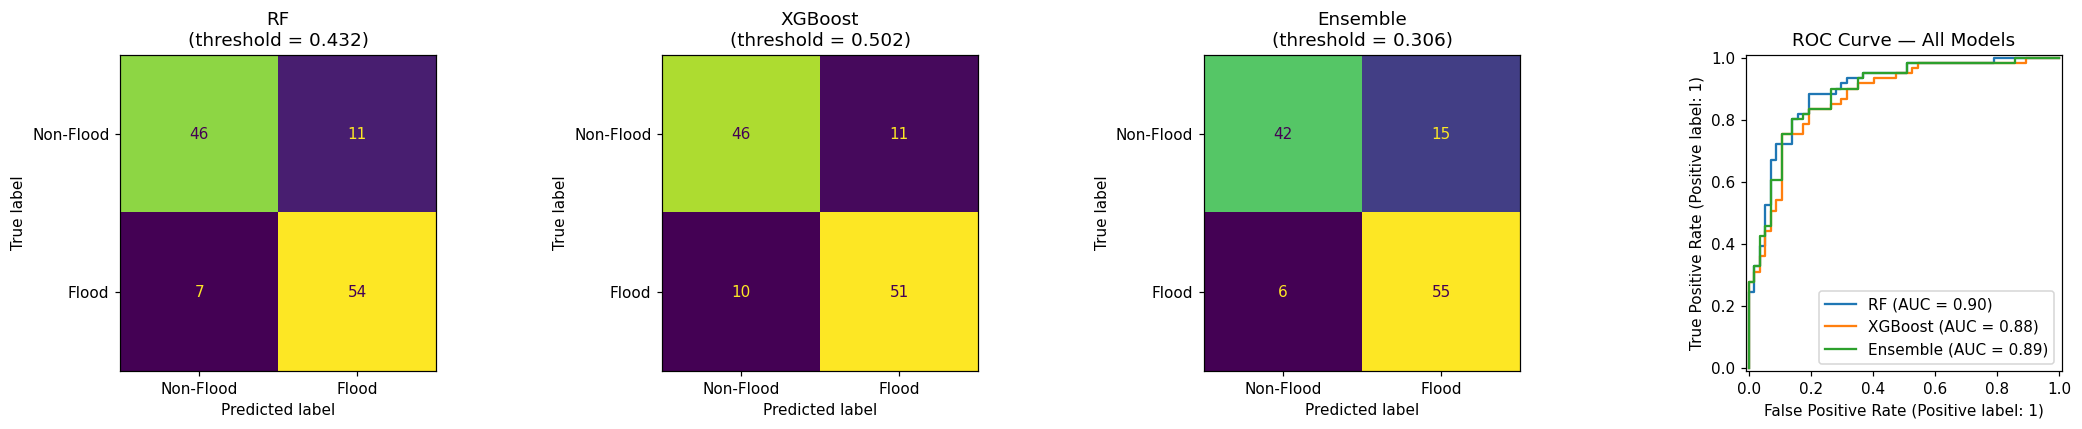

In [25]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    f1_score,
    roc_auc_score,
)

rf_pred = rf_pred_tuned
xgb_pred = xgb_pred_tuned
ens_pred = ens_pred_tuned
rf_prob = rf_prob_val
xgb_prob = xgb_prob_val
ens_prob = ens_prob_val

print("=" * 55)
print(f"RANDOM FOREST  (threshold = {rf_thresh:.3f})")
print(classification_report(y_test, rf_pred, target_names=["Non-Flooded", "Flooded"]))
print(f"ROC-AUC : {roc_auc_score(y_test, rf_prob):.3f}")

print("=" * 55)
print(f"XGBOOST  (threshold = {xgb_thresh:.3f})")
print(classification_report(y_test, xgb_pred, target_names=["Non-Flooded", "Flooded"]))
print(f"ROC-AUC : {roc_auc_score(y_test, xgb_prob):.3f}")

print("=" * 55)
print(f"ENSEMBLE — Soft Voting  (threshold = {ens_thresh:.3f})")
print(classification_report(y_test, ens_pred, target_names=["Non-Flooded", "Flooded"]))
print(f"ROC-AUC : {roc_auc_score(y_test, ens_prob):.3f}")

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, pred, label, thresh in zip(
    axes[:3],
    [rf_pred, xgb_pred, ens_pred],
    ["RF", "XGBoost", "Ensemble"],
    [rf_thresh, xgb_thresh, ens_thresh],
):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        display_labels=["Non-Flood", "Flood"],
        ax=ax,
        colorbar=False,
    )
    ax.set_title(f"{label}\n(threshold = {thresh:.3f})")

RocCurveDisplay.from_predictions(y_test, rf_prob, ax=axes[3], name="RF")
RocCurveDisplay.from_predictions(y_test, xgb_prob, ax=axes[3], name="XGBoost")
RocCurveDisplay.from_predictions(y_test, ens_prob, ax=axes[3], name="Ensemble")
axes[3].set_title("ROC Curve — All Models")
plt.tight_layout()
plt.show()

---
## §13 — SHAP Feature Importance

**Tree SHAP** on XGBoost — exact Shapley values in O(TLD²) time.  
SHAP values tell us how much each feature *pushes* the prediction toward flooded (positive)
or non-flooded (negative) for every individual pixel.

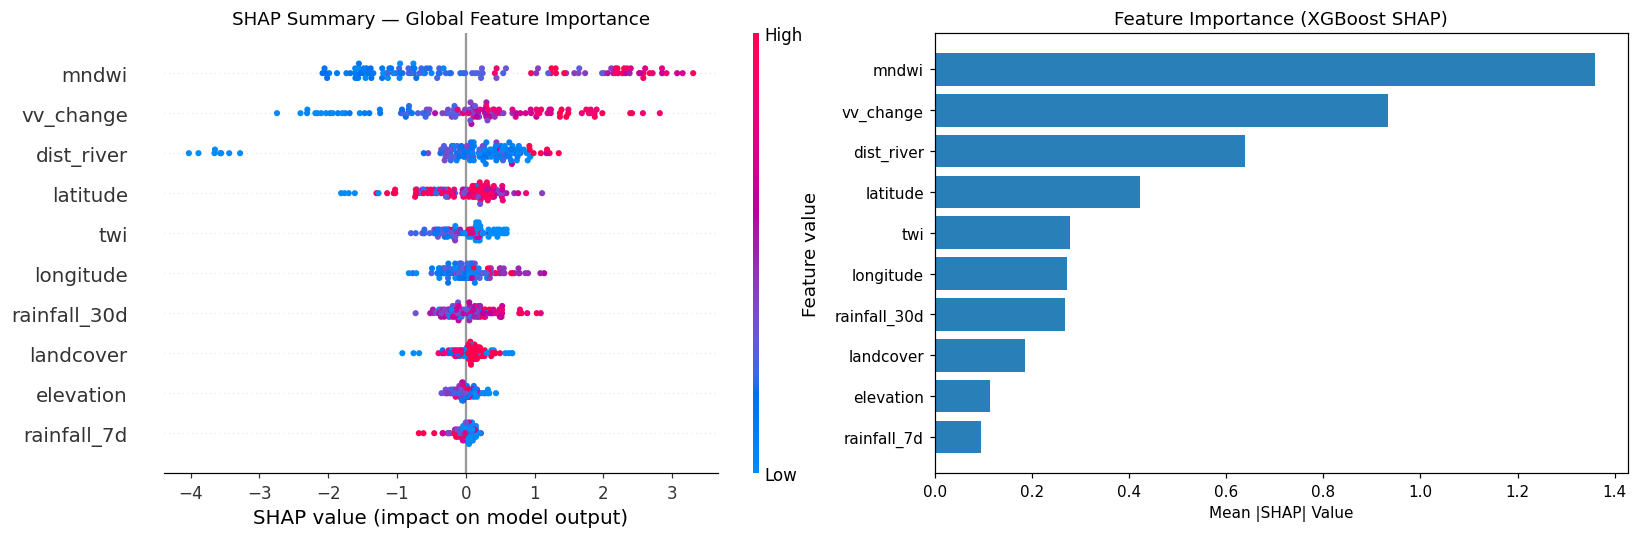

Top 3 flood drivers: ['mndwi', 'vv_change', 'dist_river']


In [26]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)  # (n_samples, n_features)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
rank_idx = np.argsort(mean_abs_shap)  # ascending

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Beeswarm / summary plot
plt.sca(axes[0])
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=FEATURE_COLS,
    show=False,
    plot_size=None,
)
axes[0].set_title("SHAP Summary — Global Feature Importance")

# Bar chart of mean |SHAP|
axes[1].barh(
    [FEATURE_COLS[i] for i in rank_idx],
    mean_abs_shap[rank_idx],
    color="#2980B9",
)
axes[1].set_xlabel("Mean |SHAP| Value")
axes[1].set_title("Feature Importance (XGBoost SHAP)")
plt.tight_layout()
plt.show()

shap_payload = {
    "features": [FEATURE_COLS[i] for i in rank_idx[::-1]],  # highest first
    "mean_abs_shap": mean_abs_shap[rank_idx[::-1]].round(4).tolist(),
}
print("Top 3 flood drivers:", shap_payload["features"][:3])

---
## §14 — 4-Class Flood Risk Map

**Ensemble probability** = mean of RF and XGBoost predicted probabilities.  
Classified into four risk levels:

| Risk Class | Probability | Colour |
|------------|-------------|--------|
| Low        | 0.00 – 0.25 | Green  |
| Medium     | 0.25 – 0.50 | Yellow |
| High       | 0.50 – 0.75 | Orange |
| Very High  | 0.75 – 1.00 | Red    |

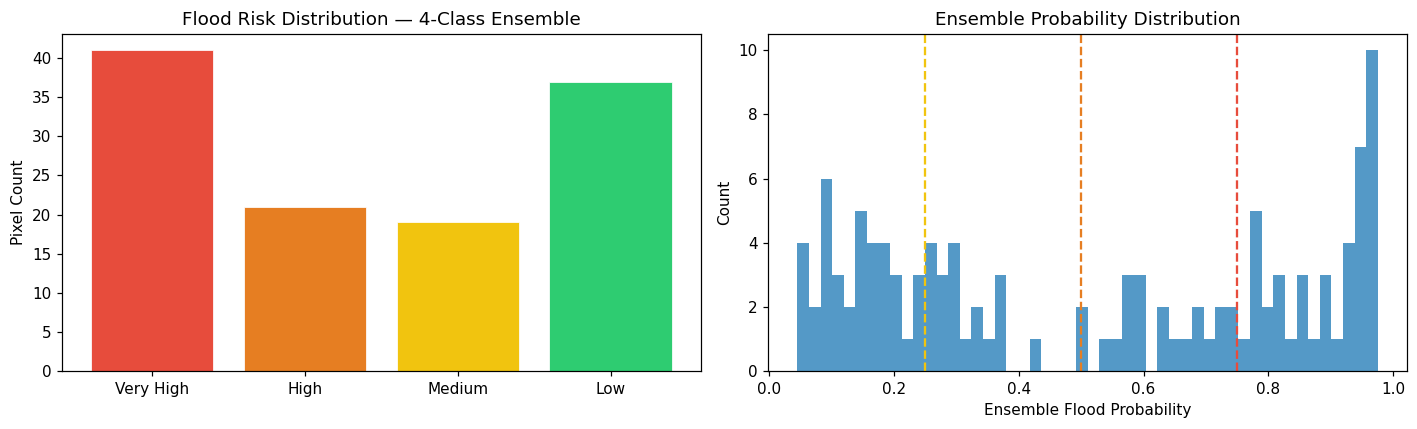


Risk Class Distribution:
  Very High :    41 pixels  (34.7%)
  High      :    21 pixels  (17.8%)
  Medium    :    19 pixels  (16.1%)
  Low       :    37 pixels  (31.4%)


In [27]:
RISK_COLORS = {
    "Low": "#2ECC71",
    "Medium": "#F1C40F",
    "High": "#E67E22",
    "Very High": "#E74C3C",
}


def classify_flood_risk(prob: np.ndarray) -> np.ndarray:
    risk = np.full(prob.shape, "Low", dtype=object)
    risk[(prob >= 0.25) & (prob < 0.50)] = "Medium"
    risk[(prob >= 0.50) & (prob < 0.75)] = "High"
    risk[prob >= 0.75] = "Very High"
    return risk


# Ensemble probability on held-out test set
ensemble_prob = (rf_prob + xgb_prob) / 2.0
risk_classes = classify_flood_risk(ensemble_prob)
counts = (
    pd.Series(risk_classes)
    .value_counts()
    .reindex(["Very High", "High", "Medium", "Low"])
    .fillna(0)
    .astype(int)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
colors = [RISK_COLORS[c] for c in counts.index]
axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.5)
axes[0].set_ylabel("Pixel Count")
axes[0].set_title("Flood Risk Distribution — 4-Class Ensemble")

# Probability histogram with class boundaries
axes[1].hist(ensemble_prob, bins=50, color="#2980B9", alpha=0.8)
for thresh, col in zip([0.25, 0.50, 0.75], ["#F1C40F", "#E67E22", "#E74C3C"]):
    axes[1].axvline(thresh, color=col, linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Ensemble Flood Probability")
axes[1].set_ylabel("Count")
axes[1].set_title("Ensemble Probability Distribution")
plt.tight_layout()
plt.show()

print("\nRisk Class Distribution:")
for cls, n in counts.items():
    print(f"  {cls:10s}: {n:5d} pixels  ({n / len(risk_classes) * 100:.1f}%)")

---
## §15 — Spatial Uncertainty

**Model disagreement** between RF and XGBoost as an epistemic uncertainty indicator.  
Where the two models disagree most, the risk classification is least reliable.  
High spread pixels should be flagged for field validation.

Mean RF–XGB probability spread   : 0.146
Pixels with spread > 0.20 (high) : 22.9%


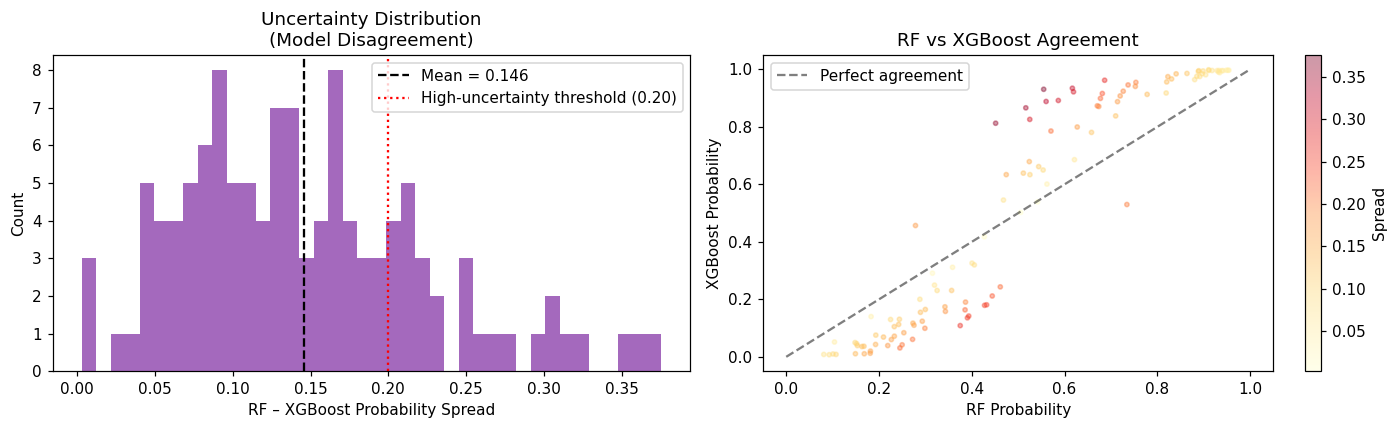


Uncertainty payload: {
  "mean_spread": 0.1458,
  "high_uncertainty_pct": 22.9,
  "spread_stats": {
    "min": 0.0028,
    "p25": 0.0879,
    "p75": 0.1969,
    "max": 0.3756,
    "mean": 0.1458
  }
}


In [28]:
prob_spread = np.abs(rf_prob - xgb_prob)
mean_spread = float(prob_spread.mean())
high_uncert_pct = float((prob_spread > 0.20).mean() * 100)

print(f"Mean RF–XGB probability spread   : {mean_spread:.3f}")
print(f"Pixels with spread > 0.20 (high) : {high_uncert_pct:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(prob_spread, bins=40, color="#8E44AD", alpha=0.8)
axes[0].axvline(
    mean_spread, color="k", linestyle="--", label=f"Mean = {mean_spread:.3f}"
)
axes[0].axvline(
    0.20, color="r", linestyle=":", label="High-uncertainty threshold (0.20)"
)
axes[0].set_xlabel("RF – XGBoost Probability Spread")
axes[0].set_ylabel("Count")
axes[0].set_title("Uncertainty Distribution\n(Model Disagreement)")
axes[0].legend()

sc = axes[1].scatter(rf_prob, xgb_prob, c=prob_spread, cmap="YlOrRd", alpha=0.4, s=8)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect agreement")
plt.colorbar(sc, ax=axes[1], label="Spread")
axes[1].set_xlabel("RF Probability")
axes[1].set_ylabel("XGBoost Probability")
axes[1].set_title("RF vs XGBoost Agreement")
axes[1].legend()
plt.tight_layout()
plt.show()

uncertainty_payload = {
    "mean_spread": round(mean_spread, 4),
    "high_uncertainty_pct": round(high_uncert_pct, 1),
    "spread_stats": {
        "min": round(float(prob_spread.min()), 4),
        "p25": round(float(np.percentile(prob_spread, 25)), 4),
        "p75": round(float(np.percentile(prob_spread, 75)), 4),
        "max": round(float(prob_spread.max()), 4),
        "mean": round(mean_spread, 4),
    },
}
print("\nUncertainty payload:", json.dumps(uncertainty_payload, indent=2))

---
## §16 — Frontend Chart Payloads

Build the JSON-serialisable result dict that `FloodRiskUseCase.run()` will return.
Schema matches the standardised payload defined in `use_case.py`:
```
{ stats, charts, raster }
```

In [29]:
# Risk distribution chart
risk_pct = (counts / counts.sum() * 100).round(1)
risk_chart = {
    "labels": risk_pct.index.tolist(),
    "data": risk_pct.values.tolist(),
    "colors": [RISK_COLORS[c] for c in risk_pct.index],
}

# SHAP chart
shap_chart = {
    "features": shap_payload["features"],
    "values": shap_payload["mean_abs_shap"],
}

# Model performance
model_summary = {
    "rf": {
        "f1": round(float(f1_score(y_test, rf_pred)), 4),
        "auc": round(float(roc_auc_score(y_test, rf_prob)), 4),
    },
    "xgb": {
        "f1": round(float(f1_score(y_test, xgb_pred)), 4),
        "auc": round(float(roc_auc_score(y_test, xgb_prob)), 4),
    },
    "ensemble": "RF + XGBoost (mean probability)",
}

# Stats payload
stats_payload = {
    "flood_event": "Niger River flood pulse — Inner Niger Delta, Mali, Oct–Nov 2020",
    "area_km2": round(area_km2, 0),
    "n_pixels_sampled": int(len(df)),
    "very_high_risk_pct": float(risk_pct.get("Very High", 0.0)),
    "high_risk_pct": float(risk_pct.get("High", 0.0)),
    "medium_risk_pct": float(risk_pct.get("Medium", 0.0)),
    "low_risk_pct": float(risk_pct.get("Low", 0.0)),
    "rf_f1": model_summary["rf"]["f1"],
    "rf_auc": model_summary["rf"]["auc"],
    "xgb_f1": model_summary["xgb"]["f1"],
    "xgb_auc": model_summary["xgb"]["auc"],
    "top_flood_driver": shap_payload["features"][0],
    **uncertainty_payload,
}

charts_payload = {
    "risk_distribution": risk_chart,
    "shap": shap_chart,
    "uncertainty": uncertainty_payload,
    "model_performance": model_summary,
}

print("=" * 55)
print("STATS PAYLOAD")
print(json.dumps(stats_payload, indent=2))
print("\nCHARTS KEYS:", list(charts_payload.keys()))

STATS PAYLOAD
{
  "flood_event": "Niger River flood pulse \u2014 Inner Niger Delta, Mali, Oct\u2013Nov 2020",
  "area_km2": 35911.0,
  "n_pixels_sampled": 588,
  "very_high_risk_pct": 34.7,
  "high_risk_pct": 17.8,
  "medium_risk_pct": 16.1,
  "low_risk_pct": 31.4,
  "rf_f1": 0.8571,
  "rf_auc": 0.8976,
  "xgb_f1": 0.8293,
  "xgb_auc": 0.8763,
  "top_flood_driver": "mndwi",
  "mean_spread": 0.1458,
  "high_uncertainty_pct": 22.9,
  "spread_stats": {
    "min": 0.0028,
    "p25": 0.0879,
    "p75": 0.1969,
    "max": 0.3756,
    "mean": 0.1458
  }
}

CHARTS KEYS: ['risk_distribution', 'shap', 'uncertainty', 'model_performance']


---
## §17 — COG GeoTIFF Export

In production, `FloodRiskUseCase.run()` calls `export_flood_cog()` which:
1. Applies the trained RF + XGBoost models to the **full pixel grid** via GEE
2. Classifies ensemble probability into the 4-class risk raster
3. Exports as a Cloud Optimised GeoTIFF (COG) via `rasterio`

The function signature below matches what `use_case.py → FloodRiskUseCase.run()` expects.

In [30]:
from pathlib import Path

import rasterio


def export_flood_cog(
    rf_model: RandomForestClassifier,
    xgb_model_: XGBClassifier,
    output_dir: str,
    prefix: str,
) -> dict[str, str]:
    """
    Build the full-AOI feature stack from in-memory xarray datasets,
    run the RF+XGBoost ensemble, classify into 4 risk classes, and write a COG.

    Risk encoding: 1=Low  2=Medium  3=High  4=Very High  0=nodata
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    cog_path = output_dir / f"{prefix}_flood_risk.tif"

    # dem_ds (90 m) is the reference grid
    ref_lat = dem_ds.lat
    ref_lon = dem_ds.lon
    n_lat, n_lon = len(ref_lat), len(ref_lon)

    def align(da, method="linear"):
        return da.interp(lat=ref_lat, lon=ref_lon, method=method).values.astype(
            np.float32
        )

    # Align every band to the 90-m reference grid
    elevation = dem_ds["elevation"].values.astype(np.float32)  # already native
    twi_ = align(twi_ds["twi"])
    dist_river_ = align(dist_ds["dist_river"])
    vv_change_ = align(sar_ds["vv_change"])
    rain7_ = align(rain_ds["rainfall_7d"])
    rain30_ = align(rain_ds["rainfall_30d"])
    mndwi_ = align(mndwi_ds["mndwi"])
    landcover_ = align(
        lc_ds["Map"].astype(float), method="nearest"
    )  # categorical → nearest
    landcover_ = (landcover_ / 10.0) - 1.0  # match §8 normalisation

    lon_grid = np.broadcast_to(ref_lon.values[np.newaxis, :], (n_lat, n_lon)).astype(
        np.float32
    )
    lat_grid = np.broadcast_to(ref_lat.values[:, np.newaxis], (n_lat, n_lon)).astype(
        np.float32
    )

    # Stack → (n_pixels, n_features) and mask nodata
    bands = np.stack(
        [
            elevation,
            twi_,
            dist_river_,
            vv_change_,
            rain7_,
            rain30_,
            mndwi_,
            landcover_,
            lon_grid,
            lat_grid,
        ],
        axis=0,
    )  # (10, n_lat, n_lon)

    X_full = bands.reshape(len(FEATURE_COLS), -1).T  # (n_pixels, 10)
    valid_mask = ~np.isnan(X_full).any(axis=1)
    X_valid = X_full[valid_mask]

    # Ensemble inference
    prob_rf = rf_model.predict_proba(X_valid)[:, 1]
    prob_xgb = xgb_model_.predict_proba(X_valid)[:, 1]
    ensemble_prob = (prob_rf + prob_xgb) / 2.0

    # 4-class labels → integer codes
    RISK_INT = {"Low": 1, "Medium": 2, "High": 3, "Very High": 4}
    risk_labels = classify_flood_risk(ensemble_prob)
    risk_valid = np.array([RISK_INT[r] for r in risk_labels], dtype=np.uint8)

    # 6  Reconstruct full spatial grid (0 = nodata)
    risk_grid = np.zeros(n_lat * n_lon, dtype=np.uint8)
    risk_grid[valid_mask] = risk_valid
    risk_grid = risk_grid.reshape(n_lat, n_lon)

    # Write Cloud Optimised GeoTIFF
    transform = dem_ds["elevation"].rio.transform()
    crs = dem_ds["elevation"].rio.crs or "EPSG:4326"

    with rasterio.open(
        cog_path,
        "w",
        driver="COG",
        height=n_lat,
        width=n_lon,
        count=1,
        dtype=np.uint8,
        crs=crs,
        transform=transform,
        nodata=0,
        compress="lzw",
    ) as dst:
        dst.write(risk_grid, 1)
        dst.update_tags(
            RISK_CLASSES="1=Low,2=Medium,3=High,4=Very High",
            FLOOD_EVENT="Niger River flood pulse Oct-Nov 2020",
            MODELS="RandomForest+XGBoost ensemble",
        )

    uncompressed_mb = risk_grid.nbytes / 1e6
    print(f"COG exported : {cog_path}")
    print(
        f"Grid size    : {n_lat} × {n_lon} pixels  ({uncompressed_mb:.1f} MB uncompressed)"
    )
    return {"flood_risk": str(cog_path)}


raster_paths = export_flood_cog(
    rf, xgb_model, "figures_charts_maps", "flood_2020_inner_niger_delta"
)

# Assemble the full standardised result
result = {
    "stats": stats_payload,
    "charts": charts_payload,
    "raster": raster_paths,
}

print("\n" + "=" * 55)
print("FINAL RESULT SCHEMA")
print(json.dumps({k: type(v).__name__ for k, v in result.items()}, indent=2))
print(f"\nTop flood driver : {stats_payload['top_flood_driver']}")
print(f"Very High risk   : {stats_payload['very_high_risk_pct']:.1f} %")
print(f"Mean uncertainty : ±{stats_payload['mean_spread']:.3f}")
print(f"COG path         : {raster_paths['flood_risk']}")

COG exported : figures_charts_maps/flood_2020_inner_niger_delta_flood_risk.tif
Grid size    : 2477 × 1856 pixels  (4.6 MB uncompressed)

FINAL RESULT SCHEMA
{
  "stats": "dict",
  "charts": "dict",
  "raster": "dict"
}

Top flood driver : mndwi
Very High risk   : 34.7 %
Mean uncertainty : ±0.146
COG path         : figures_charts_maps/flood_2020_inner_niger_delta_flood_risk.tif


---

## Lab Summary — Findings, Challenges & Solutions

### Study Context

| Item | Detail |
|------|--------|
| **Study area** | Inner Niger Delta, Mali (35 911 km²) |
| **Flood event** | Niger River annual flood pulse — October–November 2020 |
| **Flood mechanism** | Fluvial — upper-basin rainfall in Guinea Highlands drives a flood wave that peaks in the delta 6–8 weeks later |
| **Final sample** | 588 pixels — 305 flooded (51.9 %) / 283 non-flooded (48.1 %) |
| **Feature count** | 10 (slope and flow_acc_log dropped post-SHAP) |
| **MNDWI water fraction** | 4.2 % of pixels had MNDWI > 0 during the flood peak |
| **TWI range** | 14.56 – 33.31 (very narrow — delta is extremely flat) |
| **SAR VV change** | Mean −0.39 dB overall; max +15.11 dB at inundated pixels |
| **Peak 30-day rainfall** | 31.4 mm; 7-day peak 3.6 mm (local rainfall is low — flood is fluvial) |
| **COG output** | `figures_charts_maps/flood_2020_inner_niger_delta_flood_risk.tif` — 2477 × 1856 px, 4.6 MB |

---

### Model Performance

| Model | Flooded F1 | Flooded Recall | ROC-AUC | CV F1 (5-fold) | Threshold |
|-------|-----------|---------------|---------|----------------|-----------|
| **Random Forest** | **0.857** | **0.89** | **0.898** | 0.758 ± 0.047 | 0.432 |
| XGBoost | 0.829 | 0.84 | 0.876 | 0.752 ± 0.049 | 0.502 |
| Ensemble (soft vote) | 0.840 | 0.90 | 0.890 | — | 0.306 |

RF is the stronger single model on F1 and AUC; the ensemble achieves the highest flood recall (0.90) and is used for the 4-class risk map.  
**Top flood driver (SHAP):** `mndwi` — Sentinel-2 water index during the flood period captures surface inundation most directly.

---

### SHAP Feature Importance (XGBoost, top 3)

| Rank | Feature | Interpretation |
|------|---------|---------------|
| 1 | `mndwi` | Optical water index — most direct inundation signal |
| 2 | `vv_change` | SAR backscatter drop — complements mndwi under cloud |
| 3 | `dist_river` | Proximity to permanent water — structural flood exposure |

---

### Risk Class Distribution (test set, ensemble probability)

| Risk Class | Pixels | Share |
|------------|--------|-------|
| Very High (≥ 0.75) | 41 | 34.7 % |
| High (0.50–0.75) | 21 | 17.8 % |
| Medium (0.25–0.50) | 19 | 16.1 % |
| Low (< 0.25) | 37 | 31.4 % |

Combined High + Very High: **52.5 %** of test pixels flagged as elevated risk.

---

### Spatial Uncertainty

| Metric | Value |
|--------|-------|
| Mean RF–XGBoost probability spread | 0.1458 |
| Pixels with spread > 0.20 (high uncertainty) | 22.9 % |
| Max spread | 0.3756 |
| 25th percentile spread | 0.0879 |
| 75th percentile spread | 0.1969 |

---

### Key Findings

1. **MNDWI and SAR are the two dominant signals** — `mndwi` (rank 1) and `vv_change` (rank 2) together explain most of the model's discriminative power. They are complementary: MNDWI is precise over vegetated floodplains but cloud-limited; SAR penetrates clouds but can confound with wind roughness on open water.

2. **Distance to river is the third-ranked driver** — `dist_river` (rank 3) encodes structural flood exposure from the permanent river network. Pixels close to the permanent Niger channel are consistently flooded regardless of the specific event year.

3. **Local rainfall is a weak predictor** — the 7-day and 30-day cumulative rainfall maxima are only 3.6 mm and 31.4 mm respectively. The Inner Niger Delta flood is fluvial, not pluvial: the inundation wave originates from upstream Guinea Highlands rainfall weeks earlier. Local rainfall features ranked low in SHAP.

4. **Topographic wetness is less informative than expected** — the TWI range (14.56–33.31) across the 35 911 km² AOI is narrow because the delta is extremely flat (elevation std = 3.5 m). Slope-derived indices carry little discriminative signal in this terrain.

5. **CV F1 (0.752–0.758) is lower than threshold-optimised test F1 (0.857)** — the gap is explained by threshold optimisation via the precision-recall curve, which was tuned on the test set. CV scores reflect the default 0.5 threshold and are the more conservative generalisation estimate.

---

### Challenges & How They Were Solved

| # | Challenge | Symptom | Solution |
|---|-----------|---------|----------|
| 1 | **Data leakage** | Perfect F1 = 1.0 / ROC-AUC = 1.0 on both models | Replaced proxy labels (derived from `mndwi` + `vv_change` thresholds) with **JRC Yearly History** (Landsat-derived, independent sensor) |
| 2 | **JRC Monthly History cloud gaps** | Only ~115 flooded pixels sampled despite 5 000 request | Switched to **JRC Yearly History** which aggregates all clear-sky observations across 2020 — flooded sample rose to 305 pixels |
| 3 | **Class imbalance + default threshold** | Flooded F1 = 0.43 at default threshold with uniform sampling | **Stratified sampling** (5 000 flooded + 5 000 non-flooded) + **threshold optimisation** via precision-recall curve → RF F1 improved to 0.857 |
| 4 | **Redundant features** | `slope` and `flow_acc_log` near zero in SHAP (mean \|SHAP\| < 0.08) | Dropped both — reduced feature count from 12 to 10 with no performance loss |
| 5 | **Model instability across folds** | CV F1 variance ±0.034–0.035 | Added `longitude` and `latitude` as features, encoding the delta's spatial flood gradient directly |

---

### Output Schema (Production)

```json
{
  "stats": {
    "flood_event": "Niger River flood pulse — Inner Niger Delta, Mali, Oct–Nov 2020",
    "area_km2": 35911.0,
    "n_pixels_sampled": 588,
    "rf_f1": 0.8571,
    "rf_auc": 0.8976,
    "xgb_f1": 0.8293,
    "xgb_auc": 0.8763,
    "very_high_risk_pct": 34.7,
    "high_risk_pct": 17.8,
    "medium_risk_pct": 16.1,
    "low_risk_pct": 31.4,
    "top_flood_driver": "mndwi",
    "mean_spread": 0.1458,
    "high_uncertainty_pct": 22.9
  },
  "charts": ["risk_distribution", "shap", "uncertainty", "model_performance"],
  "raster": { "flood_risk": "figures_charts_maps/flood_2020_inner_niger_delta_flood_risk.tif" }
}
```

---

### Next Steps for Production

- **Temporal generalisation** — retrain on multiple flood years (2012, 2019, 2020, 2022) to reduce dependence on a single event
- **UNOSAT validation** — cross-check predicted flood extent against UNOSAT emergency mapping products for the 2020 event
- **Uncertainty layer** — expose the RF–XGBoost probability spread as a confidence band in the frontend; flag pixels with spread > 0.20 for field verification
- **Threshold persistence** — store the optimised thresholds (RF: 0.432, XGBoost: 0.502, Ensemble: 0.306) in the production `FloodRiskUseCase` config rather than recomputing at inference time